In [21]:
import argparse
import datetime
import math
import os
from time import time
from typing import Any, List, Tuple

import mlflow
import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed
from sparsemax import Sparsemax

from artifacts import (
    build_plot_df_wrapper,
    save_csv_artifact,
    save_plot_strategy,
)
from BoTorchOptimizer import BoTorchOptimizer
from data import (
    apply_final_treatment,
    join_metadata,
    load_metadata_artefacts,
    load_odds,
)
from dependencies.config import load_config
from dependencies.utils import get_bet_return, save_df_as_parquet, softmax, sparsemax
from filter import filter_by_linear_combination
from GameProbs import GameProbs

config = load_config("config/config.yml")

sparsemax = Sparsemax(dim=-1)

from loguru import logger


In [22]:

def setup(args):
    metadata, gameid_to_outcome = load_metadata_artefacts(config.metadata_path)
    odds = load_odds(config.odds_path, args.bookmakers)
    print(odds.shape)
    odds = join_metadata(odds, metadata)

    odds = odds.sort_values(["Datetime", "GameId"], ascending=True)

    odds = odds[(odds.Datetime.apply(str)>="2023-04-15")]
    
    return odds, gameid_to_outcome


def process_group(
    group: Tuple[str, pd.DataFrame], gameid_to_outcome, args
) -> List[List[Any]]:
    is_valid_solution = True

    date, group_data = group

    games_ids = group_data["GameId"].unique()

    # Initialize dict to store dataframes of favorable bet opportunities
    odds_dict = {}
    # Initialize dict to store 7x7 matrices/dataframes of real probabilities
    df_probs_dict = {}

    if len(games_ids) > args.min_games:
        for game_id in games_ids:
            df = GameProbs(game_id).build_dataframe()

            odds_sample = group_data[(group_data.GameId == game_id)]
            odds_sample = apply_final_treatment(df_odds=odds_sample, df_real_prob=df)
            if not args.do_baseline:
                odds_sample = filter_by_linear_combination(odds_sample, n=args.bets_per_game, weight=args.weight)
            else:
                odds_sample = odds_sample.sample(1)
            odds_dict[game_id] = odds_sample
            df_probs_dict[game_id] = df

        odds_dt = pd.concat(odds_dict.values())

        if len(odds_dt) <= config.max_vector_length and len(odds_dt) > 1:
        #if len(odds_dt) <= config.max_vector_length :
            iteration_date = odds_dt.Datetime.apply(str).unique()[0]
            print(f"Date: {iteration_date}")

            odds_favorable = torch.tensor(np.array(odds_dt["Odd"]))
            real_prob_favorable = torch.tensor(np.array(odds_dt["real_prob"]))
            event_favorable = list(odds_dt["BetMap"].values)
            games_ids = np.array(odds_dt["GameId"])
            time_limit_flag = None

            if not args.do_baseline:
                # try:
                print("Execution of minimization task...")


                optimizer_instance = MO(
                    n_iterations=args.n_iterations,
                    public_odd=odds_favorable,
                    real_probabilities=real_prob_favorable,
                    event=event_favorable,
                    games_ids=games_ids,
                    df_probs_dict=df_probs_dict,
                )

                solution = optimizer_instance.run_optimization()

                print("Finalization of minimization task...")

                # except ValueError:
                # continue

                if any(math.isnan(x) for x in solution):
                    is_valid_solution = False
                odds_dt["solution"] = sparsemax(torch.tensor(np.array([solution]))).tolist()[0]
                #odds_dt["solution"] = softmax(solution)

            else:
                odds_dt["solution"] = 1

            save_df_as_parquet(odds_dt, str(date))

            track_record = []

            for game_id, game_data in odds_dt.groupby("GameId", sort=False):
                scenario = gameid_to_outcome[game_id]
                financial_return = get_bet_return(
                    df=game_data, allocation_array=game_data.solution, scenario=scenario
                )

                print(
                    f"game_id: {game_id}; financial_return: {np.round(financial_return, 3)}"
                )

                track_record.append(
                    [
                        str(game_id),
                        financial_return,
                        len(game_data),
                        odds_dt.n_favorable_bets.values[0],
                        time_limit_flag,
                        is_valid_solution,
                        iteration_date,
                    ]
                )

            return track_record

In [23]:
#args = parser.parse_args()
parser = argparse.ArgumentParser()
parser.add_argument(
    '--bookmakers',
    nargs='+',
    default=None,
    help='A list of strings',
)
parser.add_argument(
    "--aggregator", type=str, help="aggregate by GameId or by Datetime"
)
parser.add_argument(
    "--min_games",
    type=int,
    default=0,
    help="threshold of minimum number of games to enter the optimization task",
)
parser.add_argument(
    "--bets_per_game", type=int, default=5, help="number of bets per game"
)
parser.add_argument(
    "--weight",
    type=float,
    default=0.5,
    help="weight of the linear combination filter",
)
parser.add_argument(
    "--n_iterations",
    type=int,
    default=10,
    help="number of iterations to run the optimization task",
)
parser.add_argument(
    "--do_baseline",
    action="store_true",
    help="flag to apply baseline logic or not, not specifying the argument return the opposite of the action",
)
parser.add_argument(
    "--n_jobs",
    type=int,
    default=1,
    help="number of jobs to run in parallel",
)
parser.add_argument(
    "--save_experiment",
    action="store_true",
    help="flag to save the experiment artefacts, not specifying the argument return the opposite of the action",
)
args = parser.parse_args([
"--aggregator", "Datetime",
"--min_games", "1",
"--bets_per_game", "2",
"--n_iterations", "10",
"--weight", "0.5",
#"--do_baseline", "False"
#"--save_experiment"
])
print(args)

odds, gameid_to_outcome = setup(args)

grouped = odds.groupby(args.aggregator)

Namespace(bookmakers=None, aggregator='Datetime', min_games=1, bets_per_game=2, weight=0.5, n_iterations=10, do_baseline=False, n_jobs=1, save_experiment=False)
(2113785, 7)


In [24]:
odds[(odds.GameId=="7290395")&(odds.Sportsbook=="1xBet")]

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime
2039283,7290395,1xBet,h2h,,home,1.400,0.714286,Palmeiras,Cuiabá,2023-04-15
2039284,7290395,1xBet,h2h,,draw,5.170,0.193424,Palmeiras,Cuiabá,2023-04-15
2039285,7290395,1xBet,h2h,,away,7.760,0.128866,Palmeiras,Cuiabá,2023-04-15
2039394,7290395,1xBet,over/under,6.5,over,23.000,0.043478,Palmeiras,Cuiabá,2023-04-15
2039395,7290395,1xBet,over/under,6.5,under,1.010,0.990099,Palmeiras,Cuiabá,2023-04-15
2039396,7290395,1xBet,over/under,7.5,over,51.000,0.019608,Palmeiras,Cuiabá,2023-04-15
2039397,7290395,1xBet,over/under,7.5,under,1.001,0.999001,Palmeiras,Cuiabá,2023-04-15
2039419,7290395,1xBet,both_score,,yes,2.145,0.466200,Palmeiras,Cuiabá,2023-04-15
2039420,7290395,1xBet,both_score,,no,1.704,0.586854,Palmeiras,Cuiabá,2023-04-15


In [38]:
from itertools import chain
df = GameProbs("7290395").build_dataframe()
sum(list(chain(*df.to_numpy())))

0.9997999999999997

In [41]:
df

,0,1,2,3,4,5,6
0,0.0245,0.0006,0.0017,0.0035,0.0058,0.0085,0.1814
1,0.0002,0.0250,0.0029,0.0057,0.0093,0.0130,0.2223
2,0.0002,0.0011,0.0146,0.0054,0.0085,0.0116,0.1732
3,0.0002,0.0009,0.0022,0.0078,0.0061,0.0081,0.1089
4,0.0001,0.0006,0.0014,0.0025,0.0047,0.0049,0.0602
5,0.0001,0.0003,0.0008,0.0014,0.0021,0.0029,0.0306
6,0.0001,0.0004,0.0009,0.0015,0.0021,0.0026,0.0264


In [25]:
for a, b in grouped:
    print(a)
    print(b)

2023-04-15
          GameId     Sportsbook Market Scenario   Bet     Odd  public_prob  \
2079131  7290394      Stake.com    h2h           home    2.44     0.409836   
2079132  7290394      Stake.com    h2h           draw    3.10     0.322581   
2079133  7290394      Stake.com    h2h           away    3.10     0.322581   
2079134  7290394  BC.Game Sport    h2h           home    2.46     0.406504   
2079135  7290394  BC.Game Sport    h2h           draw    3.10     0.322581   
...          ...            ...    ...      ...   ...     ...          ...   
2036111  7290402        Midnite  exact   10 : 6     o  101.00     0.009901   
2036112  7290402        Midnite  exact   10 : 7     o  101.00     0.009901   
2036113  7290402        Midnite  exact   10 : 8     o  101.00     0.009901   
2036114  7290402        Midnite  exact   10 : 9     o  101.00     0.009901   
2036115  7290402        Midnite  exact  10 : 10     o  101.00     0.009901   

               Home        Away    Datetime  
207913

In [26]:
# Function to get the n-th group and its DataFrame
def get_nth_group(grouped, n):
    for i, (group_key, group_df) in enumerate(grouped):
        if i == n:
            return group_key, group_df
    raise IndexError("Group index out of range")
n = 0
group = get_nth_group(grouped, n)

In [27]:
date, group_data = group
date

datetime.date(2023, 4, 15)

In [28]:
financial_return_aggregated_list = []

In [186]:
%%timeit -n 10 -r 1

print(f"Processing group {n}...")

Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
Processing group 0...
16.1 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)


In [187]:
%%timeit -n 20 -r 1

games_ids = group_data["GameId"].unique()

# Initialize dict to store dataframes of favorable bet opportunities
odds_dict = {}
# Initialize dict to store 7x7 matrices/dataframes of real probabilities
df_probs_dict = {}

if len(games_ids) > args.min_games:
    for game_id in games_ids:
        df = GameProbs(game_id).build_dataframe()

        odds_sample = group_data[(group_data.GameId == game_id)]
        odds_sample = apply_final_treatment(df_odds=odds_sample, df_real_prob=df)
        if not args.do_baseline:
            odds_sample = filter_by_linear_combination(odds_sample, n=args.bets_per_game, weight=args.weight)
        else:
            odds_sample = odds_sample.sample(1)
        odds_dict[game_id] = odds_sample
        df_probs_dict[game_id] = df

    odds_dt = pd.concat(odds_dict.values())

    if len(odds_dt) <= config.max_vector_length and len(odds_dt) > 1:
    #if len(odds_dt) <= config.max_vector_length :
        iteration_date = odds_dt.Datetime.apply(str).unique()[0]
        print(f"Date: {iteration_date}")

        odds_favorable = torch.tensor(np.array(odds_dt["Odd"]))
        real_prob_favorable = torch.tensor(np.array(odds_dt["real_prob"]))
        event_favorable = list(odds_dt["BetMap"].values)
        games_ids = np.array(odds_dt["GameId"])
        time_limit_flag = None

        if not args.do_baseline:
            # try:
            print("Execution of minimization task...")


            optimizer_instance = BoTorchOptimizer(
                n_iterations=args.n_iterations,
                public_odd=odds_favorable,
                real_probabilities=real_prob_favorable,
                event=event_favorable,
                games_ids=games_ids,
                df_probs_dict=df_probs_dict,
            )

            solution = optimizer_instance.run_optimization()

            print("Finalization of minimization task...")

            # except ValueError:
            # continue

            if any(math.isnan(x) for x in solution):
                is_valid_solution = False
            #odds_dt["solution"] = sparsemax(torch.tensor(np.array([solution]))).tolist()[0]
            odds_dt["solution"] = softmax(solution)

        else:
            odds_dt["solution"] = 1

        track_record = []
            
        financial_return_aggregated = 0

        for game_id, game_data in odds_dt.groupby("GameId", sort=False):
            scenario = gameid_to_outcome[game_id]
            financial_return = get_bet_return(
                df=game_data, allocation_array=game_data.solution, scenario=scenario
            )
            financial_return_aggregated += financial_return
            logger.info(
                f"game_id: {game_id}; financial_return: {np.round(financial_return, 3)}; scenario: {scenario}"
            )

        if financial_return_aggregated < 1:
            logger.warning(f"Negative return for the day {iteration_date}")
        
        else:
            logger.info(f"Positive return for the day {iteration_date}")
financial_return_aggregated_list.append(financial_return_aggregated)

Date: 2023-10-19
Execution of minimization task...


2024-08-02 14:06:08.819 | INFO     | __main__:inner:73 - game_id: 7290104; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:08.820 | INFO     | __main__:inner:73 - game_id: 7290105; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:08.822 | INFO     | __main__:inner:73 - game_id: 7290106; financial_return: 0.713; scenario: 1 : 3
2024-08-02 14:06:08.824 | INFO     | __main__:inner:73 - game_id: 7290107; financial_return: 0.0; scenario: 2 : 0
2024-08-02 14:06:08.825 | INFO     | __main__:inner:73 - game_id: 7290108; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:08.826 | INFO     | __main__:inner:73 - game_id: 7290111; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:08.826 | WARNING  | __main__:inner:78 - Negative return for the day 2023-10-19


Finalization of minimization task...
Date: 2023-10-19
Execution of minimization task...


2024-08-02 14:06:10.265 | INFO     | __main__:inner:73 - game_id: 7290104; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:10.266 | INFO     | __main__:inner:73 - game_id: 7290105; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:10.268 | INFO     | __main__:inner:73 - game_id: 7290106; financial_return: 0.352; scenario: 1 : 3
2024-08-02 14:06:10.269 | INFO     | __main__:inner:73 - game_id: 7290107; financial_return: 0.0; scenario: 2 : 0
2024-08-02 14:06:10.270 | INFO     | __main__:inner:73 - game_id: 7290108; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:10.271 | INFO     | __main__:inner:73 - game_id: 7290111; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:10.272 | WARNING  | __main__:inner:78 - Negative return for the day 2023-10-19


Finalization of minimization task...
Date: 2023-10-19
Execution of minimization task...


...

Finalization of minimization task...
Date: 2023-10-19
Execution of minimization task...


2024-08-02 14:06:39.299 | INFO     | __main__:inner:73 - game_id: 7290104; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:39.301 | INFO     | __main__:inner:73 - game_id: 7290105; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:39.303 | INFO     | __main__:inner:73 - game_id: 7290106; financial_return: 0.249; scenario: 1 : 3
2024-08-02 14:06:39.304 | INFO     | __main__:inner:73 - game_id: 7290107; financial_return: 0.0; scenario: 2 : 0
2024-08-02 14:06:39.306 | INFO     | __main__:inner:73 - game_id: 7290108; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:39.307 | INFO     | __main__:inner:73 - game_id: 7290111; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:39.307 | WARNING  | __main__:inner:78 - Negative return for the day 2023-10-19


Finalization of minimization task...
Date: 2023-10-19
Execution of minimization task...


2024-08-02 14:06:40.812 | INFO     | __main__:inner:73 - game_id: 7290104; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:40.813 | INFO     | __main__:inner:73 - game_id: 7290105; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:40.814 | INFO     | __main__:inner:73 - game_id: 7290106; financial_return: 0.322; scenario: 1 : 3
2024-08-02 14:06:40.816 | INFO     | __main__:inner:73 - game_id: 7290107; financial_return: 0.0; scenario: 2 : 0
2024-08-02 14:06:40.817 | INFO     | __main__:inner:73 - game_id: 7290108; financial_return: 0.0; scenario: 0 : 2
2024-08-02 14:06:40.818 | INFO     | __main__:inner:73 - game_id: 7290111; financial_return: 0.0; scenario: 1 : 0
2024-08-02 14:06:40.819 | WARNING  | __main__:inner:78 - Negative return for the day 2023-10-19


Finalization of minimization task...
1.68 s ± 0 ns per loop (mean ± std. dev. of 1 run, 20 loops each)


In [188]:
financial_return_aggregated_list

[0.7132572084665298,
 0.3524485519528389,
 0.20929315961897374,
 0.3373180951923132,
 0.3874982589483261,
 0.4030041477829218,
 0.38521407000720503,
 0.3831688280403614,
 0.5779171323776245,
 0.20093852132558823,
 0.37642129689455034,
 0.277207292311455,
 0.5140137203037739,
 0.6235132548213005,
 0.30236092254519464,
 0.2142768267542124,
 0.4781903526186943,
 0.37300983123481274,
 0.24888935491442682,
 0.32247492387890814]

(array([2., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1.,
        3., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.20093852, 0.2111849 , 0.22143127, 0.23167764, 0.24192402,
        0.25217039, 0.26241676, 0.27266314, 0.28290951, 0.29315589,
        0.30340226, 0.31364863, 0.32389501, 0.33414138, 0.34438775,
        0.35463413, 0.3648805 , 0.37512687, 0.38537325, 0.39561962,
        0.405866  , 0.41611237, 0.42635874, 0.43660512, 0.44685149,
        0.45709786, 0.46734424, 0.47759061, 0.48783699, 0.49808336,
        0.50832973, 0.51857611, 0.52882248, 0.53906885, 0.54931523,
        0.5595616 , 0.56980798, 0.58005435, 0.59030072, 0.6005471 ,
        0.61079347, 0.62103984, 0.63128622, 0.64153259, 0.65177897,
        0.66202534, 0.67227171, 0.68251809, 0.69276446, 0.70301083,
        0.71325721]),
 <BarContainer object of 50 artists>)

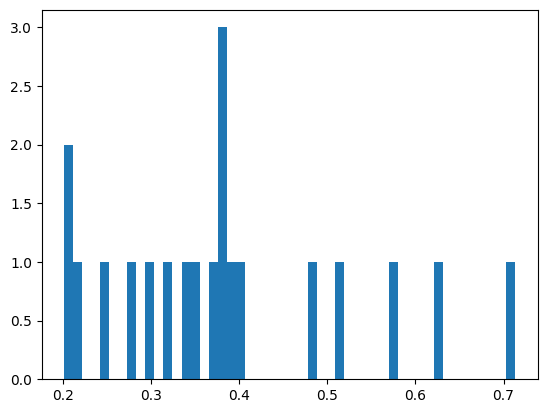

In [189]:
import matplotlib.pyplot as plt
plt.hist(financial_return_aggregated_list, bins=50)

In [191]:
group_data

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime
2030317,7290104,Stake.com,h2h,,home,2.28,0.438596,Vasco da Gama,Fortaleza,2023-10-19
2030318,7290104,Stake.com,h2h,,draw,2.90,0.344828,Vasco da Gama,Fortaleza,2023-10-19
2030319,7290104,Stake.com,h2h,,away,3.20,0.312500,Vasco da Gama,Fortaleza,2023-10-19
2030320,7290104,Betwinner,h2h,,home,2.21,0.452489,Vasco da Gama,Fortaleza,2023-10-19
2030321,7290104,Betwinner,h2h,,draw,3.28,0.304878,Vasco da Gama,Fortaleza,2023-10-19
...,...,...,...,...,...,...,...,...,...,...
2087832,7290111,LeoVegas Sport,exact,5 : 2,o,141.00,0.007092,Bahia,Internacional,2023-10-19
2087833,7290111,Betobet,exact,5 : 3,o,401.00,0.002494,Bahia,Internacional,2023-10-19
2087834,7290111,20Bet,exact,6 : 0,o,100.00,0.010000,Bahia,Internacional,2023-10-19
2087835,7290111,Betobet,exact,6 : 1,o,351.00,0.002849,Bahia,Internacional,2023-10-19


In [198]:
group_data[group_data.GameId == "7290104"].Scenario.value_counts(dropna=False)

Scenario
         87
+2/-2     3
+1/-1     3
-2/+2     3
-3/+3     3
         ..
1 : 5     1
2 : 0     1
2 : 1     1
2 : 2     1
6 : 2     1
Name: count, Length: 64, dtype: int64

In [194]:
odds_dt.sort_values("solution", ascending=False)

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime,BetMap,real_prob,bet_flag,n_favorable_bets,odd_dist,score,expected_return,solution
67,7290104,Stake.com,over/under,2.5,over,2.22,0.450450,Vasco da Gama,Fortaleza,2023-10-19,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, ...",0.8508,True,66,0.470557,0.660678,1.888776,0.339952
97,7290105,Stake.com,over/under,2.5,over,2.30,0.434783,Palmeiras,Atlético Mineiro,2023-10-19,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, ...",0.8499,True,78,0.488431,0.669165,1.954770,0.189943
99,7290105,Fezbet,over/under,3.5,over,4.33,0.230947,Palmeiras,Atlético Mineiro,2023-10-19,"[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...",0.7765,True,78,0.702580,0.739540,3.362245,0.150718
97,7290108,Stake.com,over/under,2.5,over,2.22,0.450450,Cruzeiro,Flamengo,2023-10-19,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, ...",0.7431,True,82,0.393823,0.568461,1.649682,0.092983
99,7290107,Fezbet,over/under,3.5,over,5.00,0.200000,Goiás,São Paulo,2023-10-19,"[0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, ...",0.7888,True,94,0.746450,0.767625,3.944000,0.037641
100,7290111,Stake.com,over/under,2.5,over,2.12,0.471698,Bahia,Internacional,2023-10-19,"[0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, ...",0.8535,True,80,0.447337,0.650418,1.809420,0.030301
79,7290106,20Bet,over/under,5.5,over,11.14,0.089767,Santos,Red Bull Bragantino,2023-10-19,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, ...",0.4699,True,67,0.808967,0.639433,5.234686,0.028445
101,7290108,Fezbet,over/under,4.5,over,8.50,0.117647,Cruzeiro,Flamengo,2023-10-19,"[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...",0.4640,True,82,0.746450,0.605225,3.944000,0.024120
101,7290107,Fezbet,over/under,4.5,over,9.50,0.105263,Goiás,São Paulo,2023-10-19,"[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...",0.6729,True,94,0.843568,0.758234,6.392550,0.023920
71,7290104,20Bet,over/under,4.5,over,7.19,0.139082,Vasco da Gama,Fortaleza,2023-10-19,"[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, ...",0.6506,True,66,0.786225,0.718412,4.677814,0.013631


In [13]:
from data import DataFrameFromBetMap
from itertools import chain

df_odds = odds_sample
df_real_prob = df

# Get flat table from instance of DataFrameFromBetMap
map_bet = DataFrameFromBetMap().get_flat()
# Add column of list of map of bets
df_odds = pd.merge(df_odds, map_bet, on=['Market', 'Bet', 'Scenario'], how='left')

assert df_odds[(df_odds.Market=="over/under")&(df_odds.Scenario.str.contains(r'\.5$', regex=True))].BetMap.isna().sum() == 0, "There are missing BetMap values for relevant over/under market"
#assert df_odds[df_odds.Market!="over/under"].BetMap.isna().sum() == 0, "There are missing BetMap values in over/under market"

df_odds = df_odds.dropna(subset=['BetMap']).reset_index(drop=True)
def add_real_prob(x: list, df_real_prob: pd.DataFrame) -> float:
    """
    Add the real probability of a bet event via the multiplicaiton
    of a list with lenght of 7x7 filled with 0's and 1's and the matrix of real
    probabilities 
    """
    bet_matrix = np.transpose(np.array(x).reshape(7,7))
    matrix_mult = bet_matrix * df_real_prob.to_numpy()

    return sum(list(chain(*matrix_mult)))

# Compute the real probabilitity of the event associated to the bet
df_odds['real_prob'] = df_odds.BetMap.apply(lambda x: add_real_prob(x, df_real_prob))

In [30]:
df_odds.iloc[93]

GameId                                                   7290395
Sportsbook                                                 1xBet
Market                                                over/under
Scenario                                                     6.5
Bet                                                         over
Odd                                                         23.0
public_prob                                             0.043478
Home                                                   Palmeiras
Away                                                      Cuiabá
Datetime                                              2023-04-15
BetMap         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...
real_prob                                                 0.6742
Name: 93, dtype: object

In [22]:
df

,0,1,2,3,4,5,6
0,0.0245,0.0006,0.0017,0.0035,0.0058,0.0085,0.1814
1,0.0002,0.0250,0.0029,0.0057,0.0093,0.0130,0.2223
2,0.0002,0.0011,0.0146,0.0054,0.0085,0.0116,0.1732
3,0.0002,0.0009,0.0022,0.0078,0.0061,0.0081,0.1089
4,0.0001,0.0006,0.0014,0.0025,0.0047,0.0049,0.0602
5,0.0001,0.0003,0.0008,0.0014,0.0021,0.0029,0.0306
6,0.0001,0.0004,0.0009,0.0015,0.0021,0.0026,0.0264


In [35]:
bet_matrix = np.transpose(np.array(df_odds.iloc[93].BetMap).reshape(7,7))
print(bet_matrix)
print(df_real_prob.to_numpy())
matrix_mult = bet_matrix * df_real_prob.to_numpy()
print(matrix_mult)
result = sum(list(chain(*matrix_mult)))
result

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 1 1]
 [0 0 0 0 1 1 1]
 [0 0 0 1 1 1 1]
 [0 0 1 1 1 1 1]
 [0 1 1 1 1 1 1]]
[[2.450e-02 6.000e-04 1.700e-03 3.500e-03 5.800e-03 8.500e-03 1.814e-01]
 [2.000e-04 2.500e-02 2.900e-03 5.700e-03 9.300e-03 1.300e-02 2.223e-01]
 [2.000e-04 1.100e-03 1.460e-02 5.400e-03 8.500e-03 1.160e-02 1.732e-01]
 [2.000e-04 9.000e-04 2.200e-03 7.800e-03 6.100e-03 8.100e-03 1.089e-01]
 [1.000e-04 6.000e-04 1.400e-03 2.500e-03 4.700e-03 4.900e-03 6.020e-02]
 [1.000e-04 3.000e-04 8.000e-04 1.400e-03 2.100e-03 2.900e-03 3.060e-02]
 [1.000e-04 4.000e-04 9.000e-04 1.500e-03 2.100e-03 2.600e-03 2.640e-02]]
[[0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.2223]
 [0.     0.     0.     0.     0.     0.0116 0.1732]
 [0.     0.     0.     0.     0.0061 0.0081 0.1089]
 [0.     0.     0.     0.0025 0.0047 0.0049 0.0602]
 [0.     0.     0.0008 0.0014 0.0021 0.0029 0.0306]
 [0.     0.0004 0.0009 0.0015 0.0021 0.0026 0.0264]]


0.6741999999999999

In [37]:
odds_dt[["solution", "Odd", "score"]]

,solution,Odd,score
6,0.000000,4.33,0.77161
4,0.000000,2.31,0.75522
2,0.783209,1.42,0.75038
8,0.000000,8.50,0.72398
2,0.216791,1.25,0.64978
4,0.000000,1.79,0.58129
6,0.000000,2.90,0.55330
8,0.000000,5.66,0.50676


In [87]:
solution

array([ 2.3594124 ,  0.46742427,  4.0703344 ,  0.90183145, -2.0635    ,
       -0.04187242, -1.9237189 ,  0.32340235,  0.05628312,  2.291533  ,
       -0.7601051 ,  3.616607  , -1.4812615 ,  0.30573812,  1.0348967 ,
       -0.5912484 ,  4.0191975 , -0.54406   , -5.3116217 , -0.42686996],
      dtype=float32)

In [80]:
solution

array([  3.897214  ,   1.4024419 ,   6.5735397 ,   1.085212  ,
         0.43374148, -10.        ,  -0.04147732,  -6.285349  ,
        -0.7573125 ,  -1.5447041 ,   4.692737  ,  -0.0546049 ,
        -4.6492615 ,  -1.4652156 ,  -3.2539277 ,   2.5623128 ,
         4.5390725 ,   1.2403467 ,  -1.806097  ,   6.364262  ],
      dtype=float32)

In [ ]:

def run_strategy(args):
    start_time = time()

    odds, gameid_to_outcome = setup(args)

    grouped = odds.groupby(args.aggregator)
    print(f"The number of jobs is: {args.n_jobs}")
    # Parallelize the group processing
    results = Parallel(n_jobs=args.n_jobs)(
        delayed(process_group)(group, gameid_to_outcome, args) for group in grouped
    )

    data = [x for x in results if x is not None]
    df_flat = pd.DataFrame([item for sublist in data for item in sublist])

    # # Start an MLflow experiment
    # with mlflow.start_run():
    #     # Log parameters (e.g., settings of the optimizer)
    #     mlflow.log_param("aggregator", args.aggregator)
    #     mlflow.log_param("min_games", args.min_games)
    #     mlflow.log_param("bookmakers", args.bookmakers)
    #     mlflow.log_param("bets_per_game", args.bets_per_game)
    #     mlflow.log_param("weight", args.weight)
    #     mlflow.log_param("do_baseline", args.do_baseline)
    #     mlflow.log_param("n_iterations", args.n_iterations)


    #     if args.save_experiment:
    #         # Create artefacts folder
    #         timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
    #         artefacts_folder = f"artefacts/{timestamp}"
    #         os.makedirs(artefacts_folder)
    #         save_csv_artifact(artefacts_folder, "result", df_flat)
    #         df_plot = build_plot_df_wrapper(artefacts_folder,  args.aggregator, args.do_baseline)
    #         save_csv_artifact(artefacts_folder, "result_plot", df_plot)
    #         save_plot_strategy(artefacts_folder, df_plot)
        
    #     mlflow.log_param("timestamp", timestamp)
    #     mlflow.log_artifact(f"{artefacts_folder}/result_plot.csv")
    #     mlflow.log_artifact(f"{artefacts_folder}/plot.PNG")
    #     mlflow.log_metric("wealth", df_plot["stake"].values[-1])

    #     # End the MLflow run
    #     mlflow.end_run()

    # elapsed_time = time() - start_time
    # print("Final Elapsed: %.3f sec" % elapsed_time)


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument(
        '--bookmakers',
        nargs='+',
        default=None,
        help='A list of strings',
    )
    parser.add_argument(
        "--aggregator", type=str, help="aggregate by GameId or by Datetime"
    )
    parser.add_argument(
        "--min_games",
        type=int,
        default=0,
        help="threshold of minimum number of games to enter the optimization task",
    )
    parser.add_argument(
        "--bets_per_game", type=int, default=5, help="number of bets per game"
    )
    parser.add_argument(
        "--weight",
        type=float,
        default=0.5,
        help="weight of the linear combination filter",
    )
    parser.add_argument(
        "--n_iterations",
        type=int,
        default=10,
        help="number of iterations to run the optimization task",
    )
    parser.add_argument(
        "--do_baseline",
        action="store_true",
        help="flag to apply baseline logic or not, not specifying the argument return the opposite of the action",
    )
    parser.add_argument(
        "--n_jobs",
        type=int,
        default=1,
        help="number of jobs to run in parallel",
    )
    parser.add_argument(
        "--save_experiment",
        action="store_true",
        help="flag to save the experiment artefacts, not specifying the argument return the opposite of the action",
    )
    args = parser.parse_args()
    print(args)
    run_strategy(args)


In [199]:
import pandas as pd
track_record = pd.read_csv("artefacts/20240801204946/result.csv")
track_record.columns = ['GameId', 'return',	'n_bets', 'n_favorable_bets', 'time_limit_flag', 'is_valid_solution', 'Datetime']
track_record

,GameId,return,n_bets,n_favorable_bets,time_limit_flag,is_valid_solution,Datetime
0,5925519,0.170555,5,447,NaN,True,2022-04-09
1,5925525,0.527716,5,447,NaN,True,2022-04-09
2,5925495,0.004500,5,298,NaN,True,2022-04-10
3,5925496,0.165267,5,298,NaN,True,2022-04-10
4,5925518,0.118976,5,298,NaN,True,2022-04-10
...,...,...,...,...,...,...,...
375,5924758,0.128448,5,33,NaN,True,2022-11-13
376,5924759,0.010461,5,33,NaN,True,2022-11-13
377,5924770,0.340423,5,33,NaN,True,2022-11-13
378,5924772,0.000431,5,33,NaN,True,2022-11-13


In [208]:
from artifacts import process_results, compute_stake, build_plot_df, save_plot_strategy

df = process_results("Datetime", False, track_record)

stake = compute_stake(df, stake=100, percentage=0.1)
stake


[100,
 96.98271764159726,
 95.66457947665029,
 100.54632712139048,
 99.32842230656273,
 98.28006869369662,
 98.18429518262211,
 97.98940489652841,
 98.80349497763002,
 100.29462732188692,
 101.45764654293856,
 102.46925154700939,
 103.13277876366635,
 103.31884211496649,
 101.77349028681344,
 102.45486266916383,
 107.06107408256113,
 108.05233818744303,
 109.79253582489446,
 109.35269920065542,
 110.80001888446691,
 112.64257453426131,
 113.60575661876653,
 117.61477888255074,
 118.28766810531877,
 119.02637504284168,
 116.61884550985475,
 117.87155064803893,
 117.54533928407085,
 117.95473673840768,
 119.1779767548263,
 114.31449687623268,
 115.51077073124965,
 116.75254501357806,
 116.67704130595712,
 110.86913834095044,
 108.44998721838596,
 110.42264750661465,
 108.38935384204977,
 108.7175131659529,
 107.25454594560642,
 108.68447657710807,
 105.36960887797261,
 105.51956569760266,
 102.67756100000987,
 103.08663726308086,
 100.29813992765231,
 100.18318857020068,
 100.87924771518

In [209]:
df_plot = build_plot_df(stake, False, df)
df_plot

,date,return,stake,n_favorable_bets
0,0,0.000000,100.000000,0
1,2022-04-09,0.698272,96.982718,447
2,2022-04-10,0.864085,95.664579,298
3,2022-04-11,1.510298,100.546327,62
4,2022-04-16,0.878871,99.328422,465
...,...,...,...,...
105,2022-11-07,1.359743,239.917087,408
106,2022-11-09,1.411507,249.789837,364
107,2022-11-10,1.368515,258.994976,399
108,2022-11-12,1.619638,275.043299,507


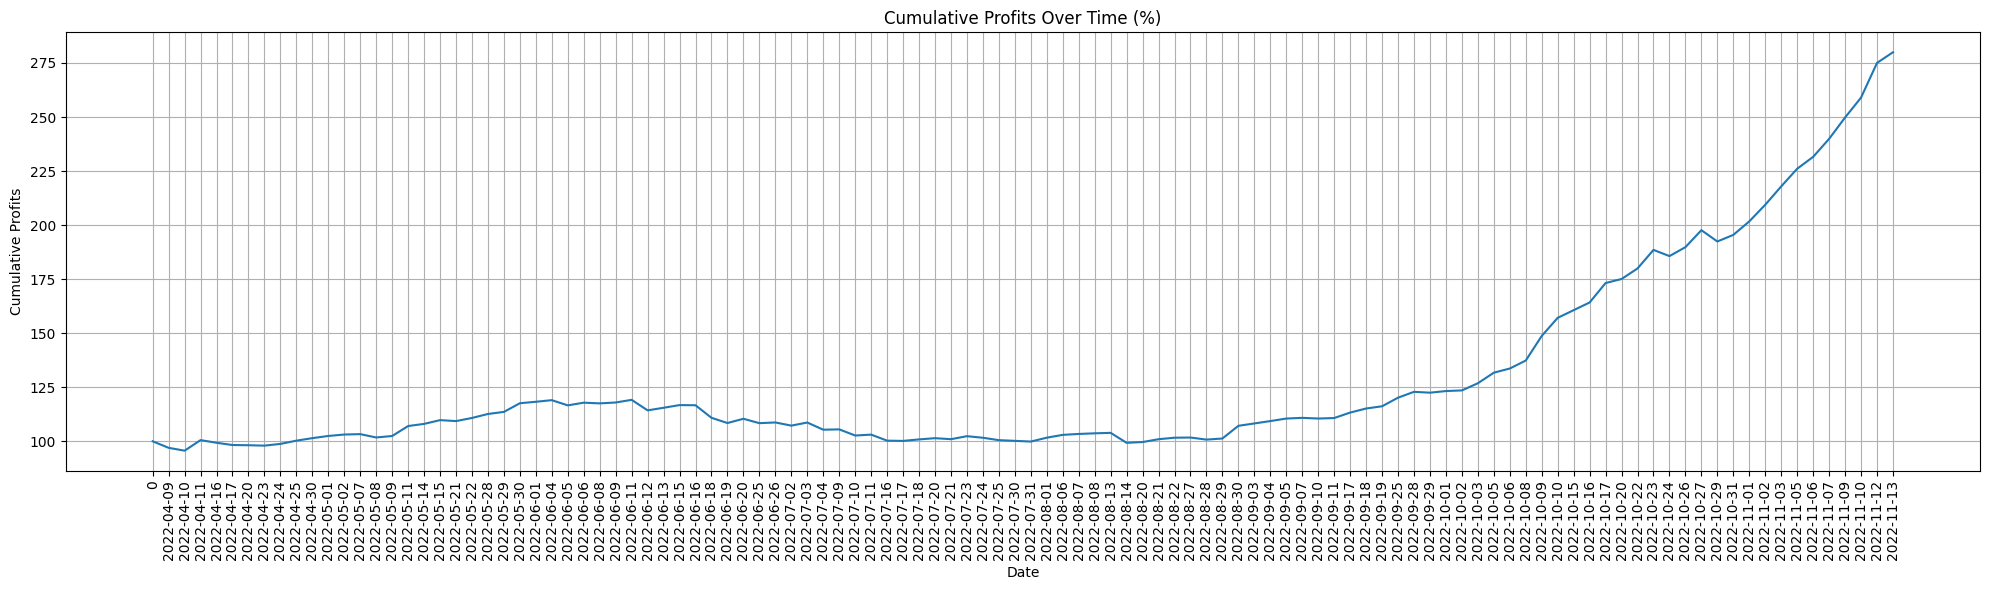

In [210]:
import matplotlib.pyplot as plt

df = df_plot
""" Create a line plot."""
plt.figure(figsize=(20, 6))
plt.plot(df.date, df.stake, linestyle='-')
plt.title('Cumulative Profits Over Time (%)')
plt.xlabel('Date')
plt.ylabel('Cumulative Profits')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()